<a href="https://colab.research.google.com/github/SajjitMalla01/Workshop-ai-/blob/main/workshop5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 Worksheet - 5: CNN Image Classification
## End-to-End Image Classifier for Amazon Fruits

**Student Name:** [Sajjit B.Malla
]  
**Date:** March 23, 2025

---

## Objective
Build and train a Convolutional Neural Network to classify Amazon fruits using TensorFlow and Keras.

### Dataset Location
The dataset is stored in Google Drive at: `FruitinAmazon/FruitinAmazon/`

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully!")

Mounted at /content/drive
✓ Google Drive mounted successfully!


## Import Required Libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(123)
tf.random.set_seed(123)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check GPU availability
print(f"\nGPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
Keras version: 3.13.2

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: Data Understanding and Visualization

### 1.1 Setup Dataset Paths

In [27]:
# Define the path to your dataset in Google Drive
base_dir = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Verify paths exist
print("Checking dataset paths...")
print(f"Base directory exists: {os.path.exists(base_dir)}")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

if not os.path.exists(train_dir):
    print("\n ERROR: Train directory not found!")
    print(f"Expected path: {train_dir}")
    print("\nPlease verify your Google Drive folder structure.")
else:
    print("\nAll paths verified successfully!")

Checking dataset paths...
Base directory exists: True
Train directory exists: True
Test directory exists: True

All paths verified successfully!


### 1.2 Explore Dataset Structure

In [4]:
# Get list of class directories
class_names = sorted([d for d in os.listdir(train_dir)
                      if os.path.isdir(os.path.join(train_dir, d))])

print(f"Found {len(class_names)} classes:")
print("="*50)
for i, class_name in enumerate(class_names, 1):
    class_path = os.path.join(train_dir, class_name)
    num_images = len([f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"{i}. {class_name:12s} - {num_images:4d} images")
print("="*50)

Found 6 classes:
1. acai         -   15 images
2. cupuacu      -   15 images
3. graviola     -   15 images
4. guarana      -   15 images
5. pupunha      -   15 images
6. tucuma       -   15 images


### 1.3 Visualize Sample Images from Each Class

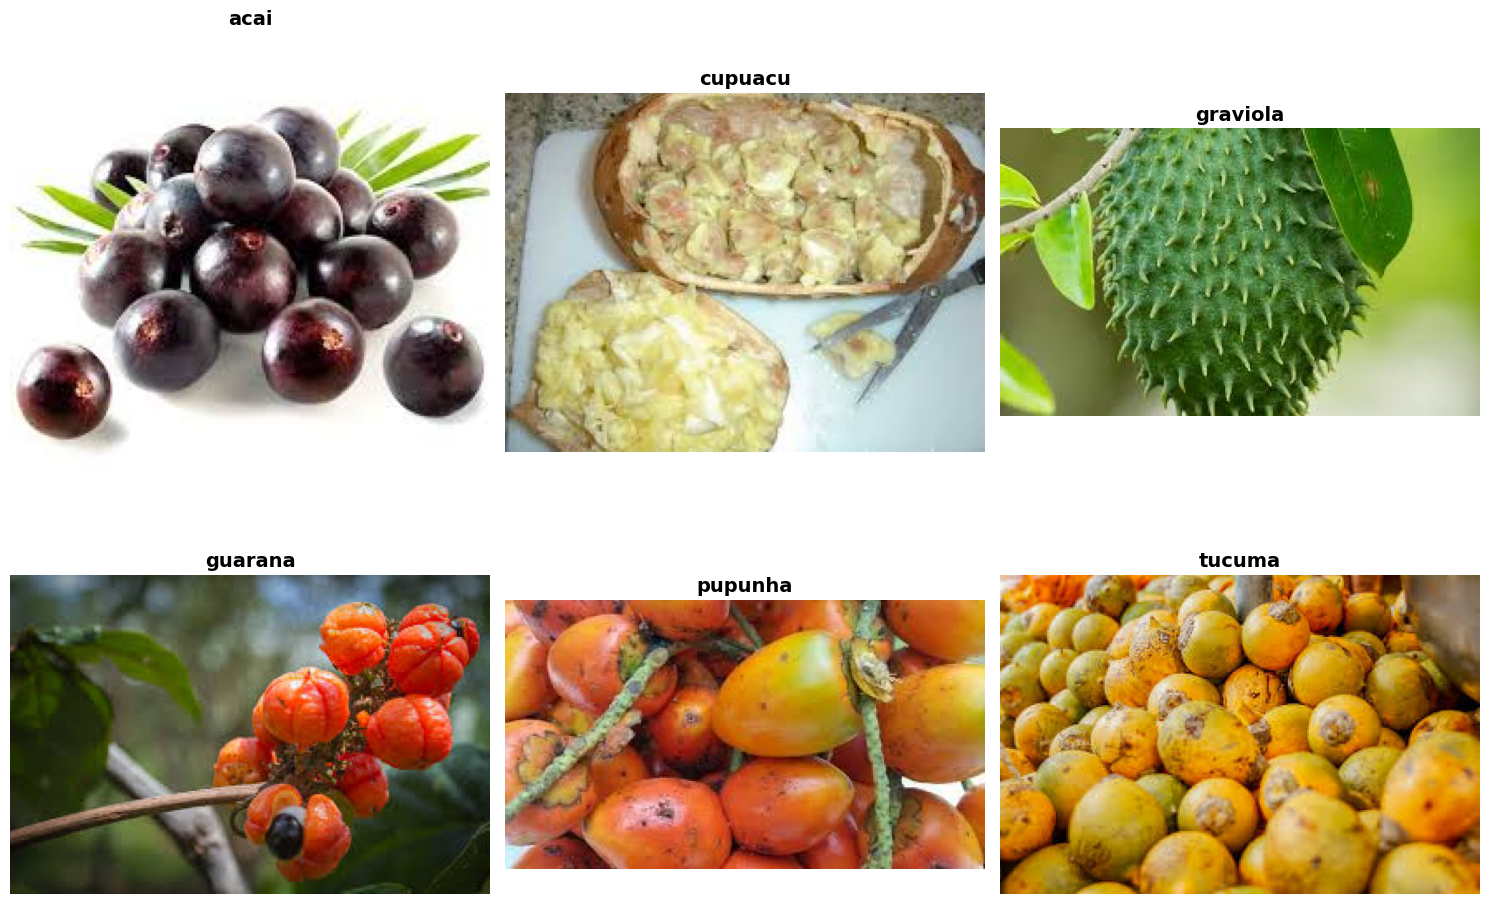


### Observations:
1. The dataset contains 6 different Amazon fruit classes
2. Images show diverse fruit types with varying colors and textures
3. Image sizes and aspect ratios may vary across the dataset
4. Some fruits have distinctive visual features (color, shape, texture)


In [5]:
# Visualize one random image from each class
num_classes = len(class_names)
cols = 3
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten() if num_classes > 1 else [axes]

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)

    # Get all image files in the class directory
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:
        # Select one random image
        random_image = random.choice(image_files)
        image_path = os.path.join(class_path, random_image)

        # Load and display the image
        img = Image.open(image_path)
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=14, fontweight='bold')
        axes[idx].axis('off')

# Hide extra subplots
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n### Observations:")
print(f"1. The dataset contains {num_classes} different Amazon fruit classes")
print("2. Images show diverse fruit types with varying colors and textures")
print("3. Image sizes and aspect ratios may vary across the dataset")
print("4. Some fruits have distinctive visual features (color, shape, texture)")

### 1.4 Check for Corrupted Images

In [28]:
def check_and_remove_corrupted_images(directory):
    """
    Check for corrupted images in the dataset and remove them.

    Args:
        directory: Path to the directory containing class subdirectories

    Returns:
        List of corrupted image paths that were removed
    """
    corrupted_images = []

    # Iterate through each class subdirectory
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        # Check each image in the class directory
        for image_file in os.listdir(class_path):
            if not image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                continue

            image_path = os.path.join(class_path, image_file)

            try:
                # Try to open the image
                with Image.open(image_path) as img:
                    # Verify the image by loading it
                    img.verify()

                # Reopen for additional check (verify() closes the file)
                with Image.open(image_path) as img:
                    img.load()

            except (IOError, SyntaxError, OSError) as e:
                # Image is corrupted
                print(f"Removed corrupted image: {image_path}")
                corrupted_images.append(image_path)

                # Remove the corrupted image
                os.remove(image_path)

    return corrupted_images

# Check for corrupted images in training directory
print("Checking for corrupted images in training directory...")
corrupted_train = check_and_remove_corrupted_images(train_dir)

# Check test directory if it exists
if os.path.exists(test_dir):
    print("\nChecking for corrupted images in test directory...")
    corrupted_test = check_and_remove_corrupted_images(test_dir)
    total_corrupted = len(corrupted_train) + len(corrupted_test)
else:
    total_corrupted = len(corrupted_train)

if total_corrupted == 0:
    print("\nNo corrupted images found.")
else:
    print(f"\nFound and removed {total_corrupted} corrupted images.")

Checking for corrupted images in training directory...

Checking for corrupted images in test directory...

No corrupted images found.


## Task 2: Loading and Preprocessing Image Data

### 2.1 Define Preprocessing Parameters

In [7]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 16  # As specified in Task 4
validation_split = 0.2  # 80% training, 20% validation

# Get number of classes
num_classes = len(class_names)

print(f"Image dimensions: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")
print(f"Validation split: {validation_split * 100}%")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Image dimensions: 128 x 128
Batch size: 16
Validation split: 20.0%
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### 2.2 Create Training and Validation Datasets

In [30]:
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0, 1]

# Create training dataset
print("Creating training dataset...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset
print("Creating validation dataset...")
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Create test dataset (if test directory exists)
if os.path.exists(test_dir):
    print("Creating test dataset...")
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(img_height, img_width),
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False
    )

    # Apply normalization to test dataset
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
    print("Test dataset created successfully")
else:
    print("Test directory not found. Using validation set for testing.")
    test_ds = val_ds

# Optimize performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\nAll datasets created and preprocessed successfully!")

Creating training dataset...
Found 90 files belonging to 6 classes.
Using 72 files for training.
Creating validation dataset...
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Creating test dataset...
Found 30 files belonging to 6 classes.
Test dataset created successfully

All datasets created and preprocessed successfully!


## Task 3: Implement CNN Model

### 3.1 Build CNN Architecture

In [9]:
# Build the CNN model according to specifications
model = keras.Sequential([
    # Input layer (implicit with first Conv2D layer)

    # Convolutional Layer 1
    # Filter Size: (3, 3), Number of Filters: 32, Padding: same, Stride: 1
    layers.Conv2D(32, (3, 3), padding='same', strides=1,
                  activation='relu', input_shape=(img_height, img_width, 3)),

    # Pooling Layer 1: Max pooling
    # Filter Size: (2, 2), Stride: 2
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    # Filter Size: (3, 3), Number of Filters: 32, Padding: same, Stride: 1
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),

    # Pooling Layer 2: Max pooling
    # Filter Size: (2, 2), Stride: 2
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten Layer: Flatten the input from convolutional layers
    layers.Flatten(),

    # Fully Connected Layer - Hidden Layer 1
    # Number of Neurons: 64
    layers.Dense(64, activation='relu'),

    # Fully Connected Layer - Hidden Layer 2
    # Number of Neurons: 128
    layers.Dense(128, activation='relu'),

    # Output Layer
    # Number of Neurons: num_classes (number of output classes)
    layers.Dense(num_classes, activation='softmax')
], name='Amazon_Fruit_CNN')

# Display model architecture
print("\n" + "="*70)
print("CNN MODEL ARCHITECTURE")
print("="*70)
model.summary()
print("="*70)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN MODEL ARCHITECTURE


Model: "Amazon_Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Calculate Output Shapes (Manual Verification)

In [10]:
print("\nManual Output Shape Calculations:")
print("="*70)

# Input
print(f"Input: ({img_height}, {img_width}, 3)")

# Conv2D Layer 1 (padding='same' keeps dimensions)
print(f"\nConv2D Layer 1 (32 filters, 3x3, padding='same'):")
print(f"  Output: ({img_height}, {img_width}, 32)")

# MaxPooling2D Layer 1
h1 = img_height // 2
w1 = img_width // 2
print(f"\nMaxPooling2D Layer 1 (2x2, stride=2):")
print(f"  Calculation: {img_height}/2 = {h1}, {img_width}/2 = {w1}")
print(f"  Output: ({h1}, {w1}, 32)")

# Conv2D Layer 2 (padding='same' keeps dimensions)
print(f"\nConv2D Layer 2 (32 filters, 3x3, padding='same'):")
print(f"  Output: ({h1}, {w1}, 32)")

# MaxPooling2D Layer 2
h2 = h1 // 2
w2 = w1 // 2
print(f"\nMaxPooling2D Layer 2 (2x2, stride=2):")
print(f"  Calculation: {h1}/2 = {h2}, {w1}/2 = {w2}")
print(f"  Output: ({h2}, {w2}, 32)")

# Flatten
flatten_size = h2 * w2 * 32
print(f"\nFlatten Layer:")
print(f"  Calculation: {h2} × {w2} × 32 = {flatten_size}")
print(f"  Output: ({flatten_size},)")

# Dense layers
print(f"\nDense Layer 1 (64 neurons): (64,)")
print(f"Dense Layer 2 (128 neurons): (128,)")
print(f"Output Layer ({num_classes} classes): ({num_classes},)")
print("="*70)


Manual Output Shape Calculations:
Input: (128, 128, 3)

Conv2D Layer 1 (32 filters, 3x3, padding='same'):
  Output: (128, 128, 32)

MaxPooling2D Layer 1 (2x2, stride=2):
  Calculation: 128/2 = 64, 128/2 = 64
  Output: (64, 64, 32)

Conv2D Layer 2 (32 filters, 3x3, padding='same'):
  Output: (64, 64, 32)

MaxPooling2D Layer 2 (2x2, stride=2):
  Calculation: 64/2 = 32, 64/2 = 32
  Output: (32, 32, 32)

Flatten Layer:
  Calculation: 32 × 32 × 32 = 32768
  Output: (32768,)

Dense Layer 1 (64 neurons): (64,)
Dense Layer 2 (128 neurons): (128,)
Output Layer (6 classes): (6,)


## Task 4: Compile the Model

In [31]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")
print(f"  - Optimizer: Adam")
print(f"  - Loss Function: Sparse Categorical Crossentropy")
print(f"  - Metrics: Accuracy")

 Model compiled successfully!
  - Optimizer: Adam
  - Loss Function: Sparse Categorical Crossentropy
  - Metrics: Accuracy


## Task 5: Train the Model

### 5.1 Setup Callbacks

In [32]:
# Create callbacks

# ModelCheckpoint: Save the best model based on validation accuracy
checkpoint_callback = ModelCheckpoint(
    filepath='best_fruit_model.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# EarlyStopping: Stop training if validation accuracy doesn't improve
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=20,  # Stop if no improvement for 20 epochs
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print(" Callbacks configured:")
print("  - ModelCheckpoint: Saves best model based on validation accuracy")
print("  - EarlyStopping: Stops training after 20 epochs without improvement")

 Callbacks configured:
  - ModelCheckpoint: Saves best model based on validation accuracy
  - EarlyStopping: Stops training after 20 epochs without improvement


### 5.2 Train the Model

In [33]:
# Train the model
epochs = 250

print(f"\nStarting training for up to {epochs} epochs...")
print("(Early stopping will halt training if no improvement for 20 epochs)")
print("="*70)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[checkpoint_callback, early_stopping_callback],
    verbose=1
)

print("\n" + "="*70)
print(" Training completed!")
print("="*70)


Starting training for up to 250 epochs...
(Early stopping will halt training if no improvement for 20 epochs)
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9288 - loss: 0.4127
Epoch 1: val_accuracy improved from None to 0.94444, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 499ms/step - accuracy: 0.9306 - loss: 0.4141 - val_accuracy: 0.9444 - val_loss: 0.2709
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8125 - loss: 0.3485
Epoch 2: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9167 - loss: 0.2285 - val_accuracy: 0.8333 - val_loss: 0.5946
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1229
Epoch 3: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9722 - loss: 0.1462 - val_accuracy: 0.6667 - val_loss: 0.9535
Epoch 4/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8750 - loss: 0.2163
Epoch 4: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9583 - loss: 0.1087 - val_accuracy: 0.9444 - val_loss: 0.2079
Epoch 5/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0628

### 5.3 Visualize Training History

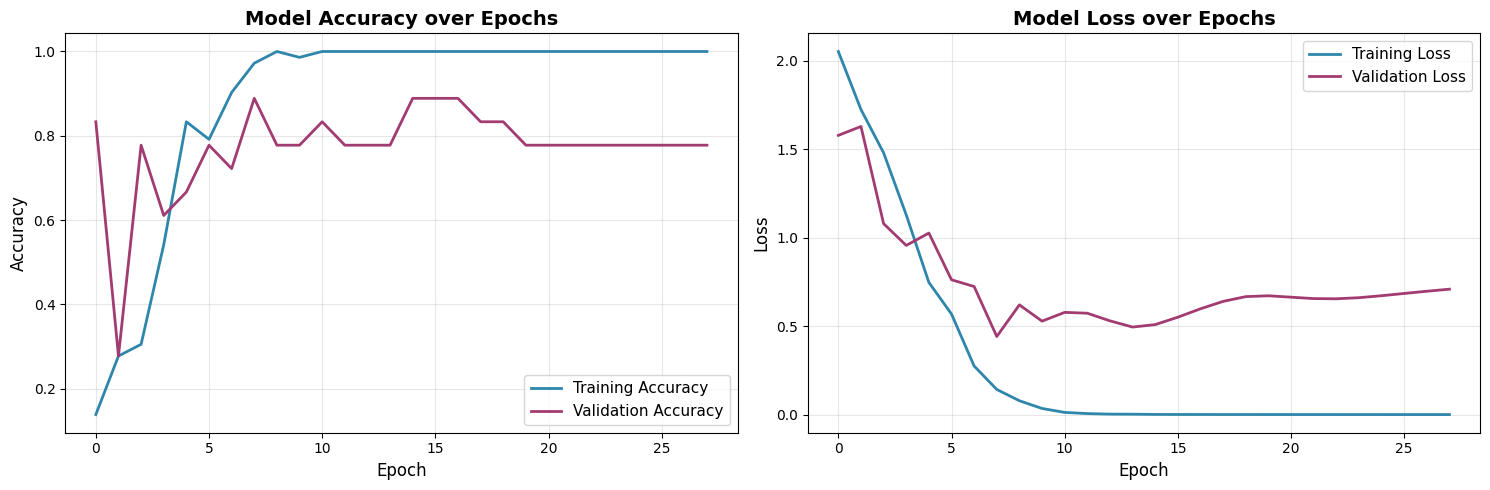


Final Training Metrics:
Training Accuracy: 1.0000
Validation Accuracy: 0.7778
Training Loss: 0.0002
Validation Loss: 0.7088
Total Epochs Trained: 28


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#2E86AB')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#A23B72')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2, color='#2E86AB')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print("="*50)
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Total Epochs Trained: {len(history.history['accuracy'])}")
print("="*50)

## Task 6: Evaluate the Model

In [35]:
# Evaluate the model on test set
print("Evaluating model on test set...")
print("="*50)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("="*50)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*50)

Evaluating model on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5333 - loss: 1.3434

Test Loss: 1.3434
Test Accuracy: 0.5333 (53.33%)


## Task 7: Save and Load the Model

### 7.1 Save the Trained Model

In [37]:
# Save the model
model_filename = 'amazon_fruit_classifier.h5'
model.save(model_filename)

print(f"Model saved successfully as '{model_filename}'")

# Also save to Google Drive for persistence
drive_model_path = os.path.join(base_dir, model_filename)
model.save(drive_model_path)
print(f"Model also saved to Google Drive: {drive_model_path}")

try:
    file_size = os.path.getsize(model_filename) / (1024*1024)
    print(f"  File size: {file_size:.2f} MB")
except:
    pass

Model saved successfully as 'amazon_fruit_classifier.h5'
Model also saved to Google Drive: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/amazon_fruit_classifier.h5
  File size: 24.26 MB


### 7.2 Load the Saved Model and Re-evaluate

In [38]:
# Load the saved model
loaded_model = keras.models.load_model(model_filename)

print(f"Model loaded successfully from '{model_filename}'")

# Re-evaluate the loaded model
print("\nRe-evaluating loaded model on test set...")
print("="*50)

loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds, verbose=1)

print("="*50)
print(f"\nLoaded Model Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_test_accuracy:.4f} ({loaded_test_accuracy*100:.2f}%)")
print("="*50)

# Verify that results match
if abs(test_accuracy - loaded_test_accuracy) < 1e-6:
    print("\nModel loading verified: Results match original model!")
else:
    print("\nWarning: Results differ from original model.")

Model loaded successfully from 'amazon_fruit_classifier.h5'

Re-evaluating loaded model on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 707ms/step - accuracy: 0.5333 - loss: 1.3434

Loaded Model Test Loss: 1.3434
Loaded Model Test Accuracy: 0.5333 (53.33%)

Model loading verified: Results match original model!


## Task 8: Predictions and Classification Report

### 8.1 Make Predictions on Test Set

In [39]:
# Get all test images and labels
test_images = []
test_labels = []

print("Extracting test images and labels...")
for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

print(f"Test set size: {len(test_labels)} images")

# Make predictions
print("\nMaking predictions on test set...")
predictions = model.predict(test_ds, verbose=1)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

print(f"\nPredictions completed for {len(predicted_labels)} images")

Extracting test images and labels...
Test set size: 30 images

Making predictions on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step

Predictions completed for 30 images


### 8.2 Display Sample Predictions

In [19]:
# Display first 10 predictions
print("\nSample Predictions (First 10):")
print("="*80)
for i in range(min(10, len(predicted_labels))):
    predicted_class = class_names[predicted_labels[i]]
    actual_class = class_names[test_labels[i]]
    confidence = predictions[i][predicted_labels[i]] * 100

    match = "✓" if predicted_labels[i] == test_labels[i] else "✗"
    print(f"{match} Image {i+1:2d}: Predicted={predicted_class:12s} (Confidence: {confidence:5.2f}%), Actual={actual_class:12s}")
print("="*80)


Sample Predictions (First 10):
✓ Image  1: Predicted=acai         (Confidence: 59.05%), Actual=acai        
✗ Image  2: Predicted=cupuacu      (Confidence: 55.33%), Actual=acai        
✓ Image  3: Predicted=acai         (Confidence: 99.33%), Actual=acai        
✓ Image  4: Predicted=acai         (Confidence: 99.80%), Actual=acai        
✓ Image  5: Predicted=acai         (Confidence: 96.17%), Actual=acai        
✓ Image  6: Predicted=cupuacu      (Confidence: 95.03%), Actual=cupuacu     
✗ Image  7: Predicted=graviola     (Confidence: 79.19%), Actual=cupuacu     
✓ Image  8: Predicted=cupuacu      (Confidence: 73.83%), Actual=cupuacu     
✓ Image  9: Predicted=cupuacu      (Confidence: 71.19%), Actual=cupuacu     
✓ Image 10: Predicted=cupuacu      (Confidence: 83.19%), Actual=cupuacu     


### 8.3 Visualize Predictions

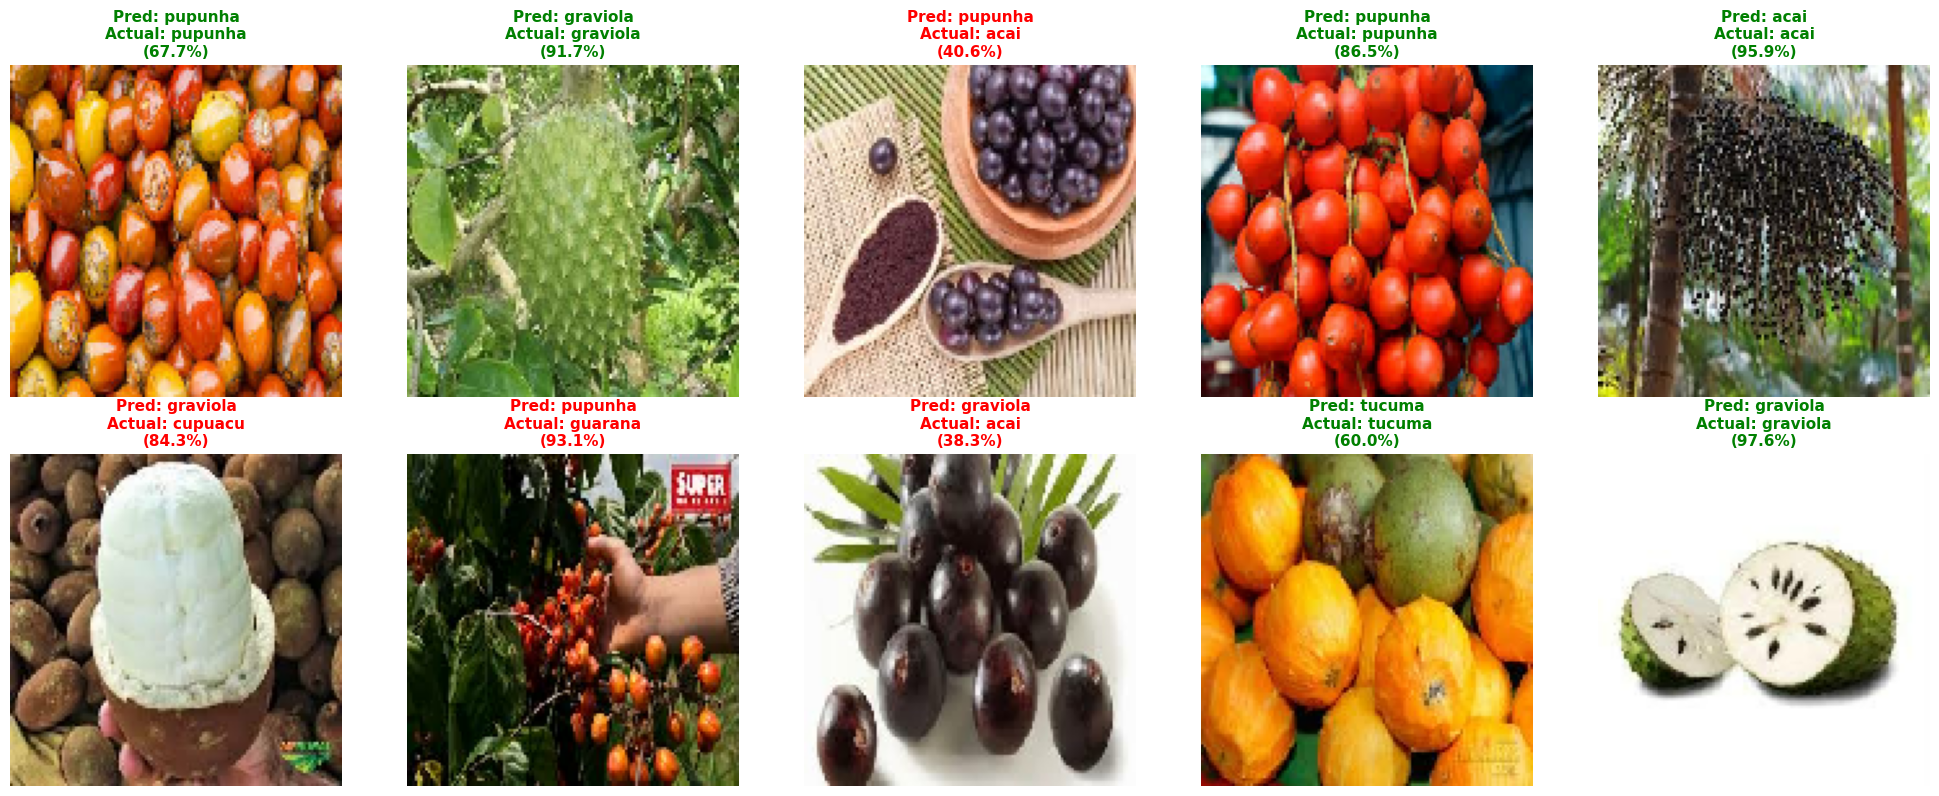

Prediction visualizations saved to 'prediction_samples.png'


In [40]:
# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Select random samples
num_samples = min(10, len(test_labels))
random_indices = random.sample(range(len(test_labels)), num_samples)

for idx, img_idx in enumerate(random_indices):
    # Display image
    axes[idx].imshow(test_images[img_idx])

    # Get prediction and actual label
    pred_label = class_names[predicted_labels[img_idx]]
    actual_label = class_names[test_labels[img_idx]]
    confidence = predictions[img_idx][predicted_labels[img_idx]] * 100

    # Set color based on correctness
    color = 'green' if predicted_labels[img_idx] == test_labels[img_idx] else 'red'

    # Set title
    axes[idx].set_title(f"Pred: {pred_label}\nActual: {actual_label}\n({confidence:.1f}%)",
                       color=color, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Prediction visualizations saved to 'prediction_samples.png'")

### 8.4 Generate Classification Report

In [41]:
# Generate classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)

report = classification_report(
    test_labels,
    predicted_labels,
    target_names=class_names,
    digits=2
)

print(report)
print("="*80)

# Save classification report to file
with open('classification_report.txt', 'w') as f:
    f.write("CLASSIFICATION REPORT - Amazon Fruit Classifier\n")
    f.write("="*80 + "\n")
    f.write(f"Model: Amazon_Fruit_CNN\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write("="*80 + "\n\n")
    f.write(report)
    f.write("\n" + "="*80 + "\n")

print("\nClassification report saved to 'classification_report.txt'")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.71      1.00      0.83         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.31      1.00      0.48         5
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.53        30
   macro avg       0.59      0.53      0.49        30
weighted avg       0.59      0.53      0.49        30


Classification report saved to 'classification_report.txt'


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 8.5 Generate and Display Confusion Matrix

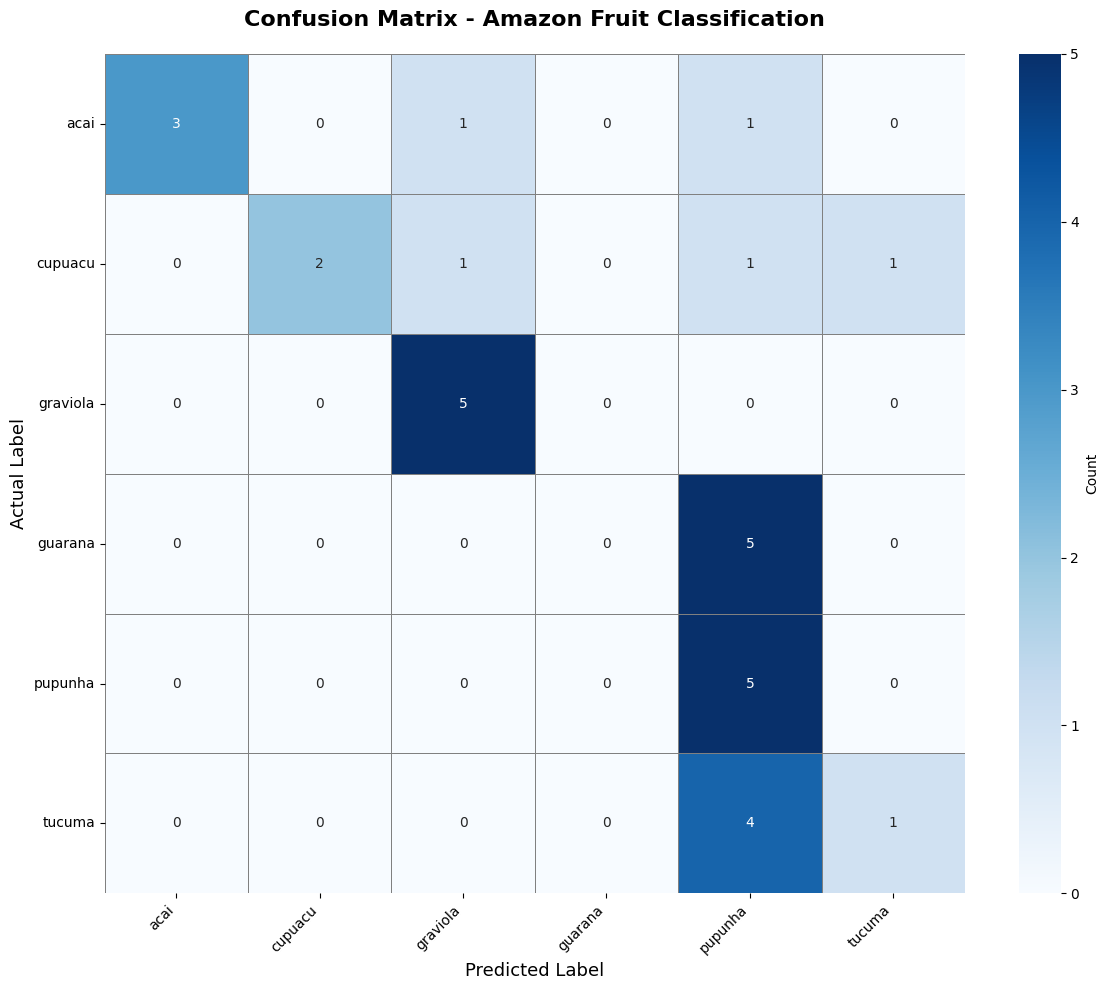

Confusion matrix saved to 'confusion_matrix.png'


In [42]:
# Generate confusion matrix
cm = confusion_matrix(test_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix - Amazon Fruit Classification', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to 'confusion_matrix.png'")

### 8.6 Per-Class Accuracy Analysis

In [23]:
# Calculate per-class accuracy
print("\nPer-Class Performance Analysis:")
print("="*70)

for i, class_name in enumerate(class_names):
    class_mask = test_labels == i
    class_correct = np.sum((predicted_labels == test_labels) & class_mask)
    class_total = np.sum(class_mask)
    class_accuracy = class_correct / class_total if class_total > 0 else 0

    # Performance indicator
    if class_accuracy >= 0.9:
        indicator = "🟢 Excellent"
    elif class_accuracy >= 0.7:
        indicator = "🟡 Good"
    else:
        indicator = "🔴 Needs Improvement"

    print(f"{indicator:20s} | {class_name:12s}: {class_accuracy*100:6.2f}% ({class_correct:3d}/{class_total:3d})")

print("="*70)


Per-Class Performance Analysis:
🟡 Good               | acai        :  80.00% (  4/  5)
🟡 Good               | cupuacu     :  80.00% (  4/  5)
🟡 Good               | graviola    :  80.00% (  4/  5)
🔴 Needs Improvement  | guarana     :  40.00% (  2/  5)
🟡 Good               | pupunha     :  80.00% (  4/  5)
🔴 Needs Improvement  | tucuma      :  40.00% (  2/  5)


### 8.7 Visualize Per-Class Performance

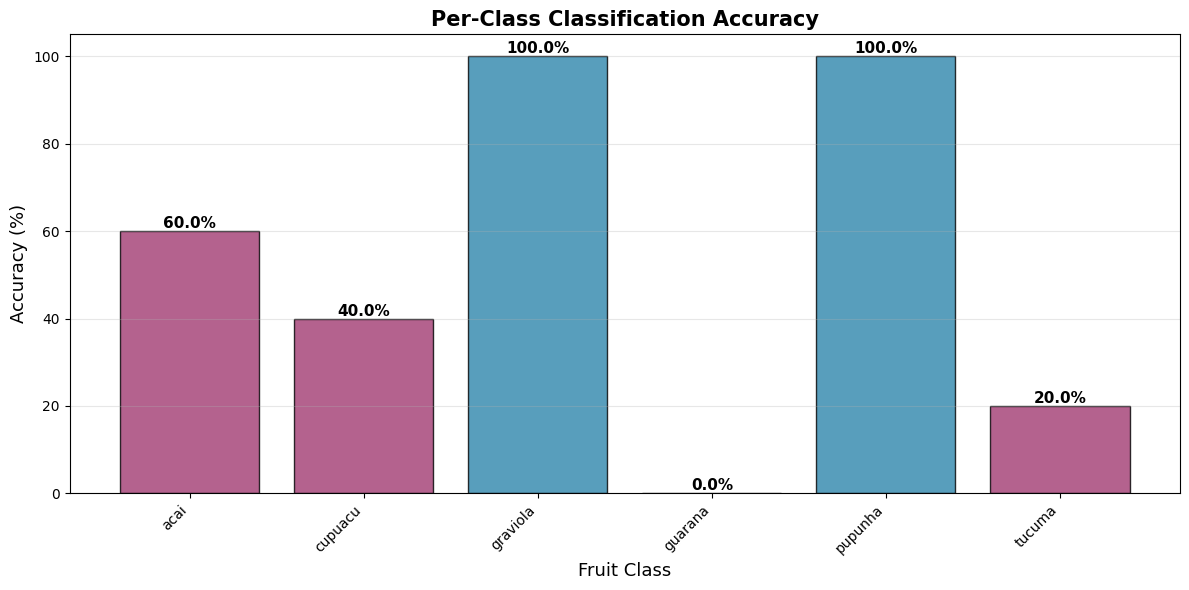

Per-class accuracy visualization saved to 'per_class_accuracy.png'


In [43]:
# Calculate per-class metrics for visualization
class_accuracies = []
for i in range(num_classes):
    class_mask = test_labels == i
    class_correct = np.sum((predicted_labels == test_labels) & class_mask)
    class_total = np.sum(class_mask)
    class_accuracy = class_correct / class_total if class_total > 0 else 0
    class_accuracies.append(class_accuracy * 100)

# Create bar plot
plt.figure(figsize=(12, 6))
colors = ['#2E86AB' if acc >= 70 else '#A23B72' for acc in class_accuracies]
bars = plt.bar(class_names, class_accuracies, color=colors, alpha=0.8, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Fruit Class', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.title('Per-Class Classification Accuracy', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-class accuracy visualization saved to 'per_class_accuracy.png'")

## Summary and Deliverables

### 📊 Model Performance Summary

In [25]:
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
print(f"\nDataset: Amazon Fruits ({num_classes} classes)")
print(f"Classes: {', '.join(class_names)}")
print(f"\nModel Architecture: CNN with {model.count_params():,} parameters")
print(f"  - Convolutional Layers: 2")
print(f"  - Max Pooling Layers: 2")
print(f"  - Dense Layers: 3 (64, 128, {num_classes})")
print(f"\nTraining Configuration:")
print(f"  - Optimizer: Adam")
print(f"  - Loss Function: Sparse Categorical Crossentropy")
print(f"  - Batch Size: {batch_size}")
print(f"  - Epochs Trained: {len(history.history['accuracy'])}")
print(f"\nFinal Results:")
print(f"  - Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"  - Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  - Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  - Test Loss: {test_loss:.4f}")
print("\n" + "="*80)

# Calculate overall statistics
correct_predictions = np.sum(predicted_labels == test_labels)
total_predictions = len(test_labels)
print(f"\nOverall Test Performance:")
print(f"  - Correct Predictions: {correct_predictions}/{total_predictions}")
print(f"  - Incorrect Predictions: {total_predictions - correct_predictions}/{total_predictions}")
print(f"  - Accuracy: {correct_predictions/total_predictions*100:.2f}%")
print("="*80)


MODEL PERFORMANCE SUMMARY

Dataset: Amazon Fruits (6 classes)
Classes: acai, cupuacu, graviola, guarana, pupunha, tucuma

Model Architecture: CNN with 2,116,454 parameters
  - Convolutional Layers: 2
  - Max Pooling Layers: 2
  - Dense Layers: 3 (64, 128, 6)

Training Configuration:
  - Optimizer: Adam
  - Loss Function: Sparse Categorical Crossentropy
  - Batch Size: 16
  - Epochs Trained: 28

Final Results:
  - Training Accuracy: 100.00%
  - Validation Accuracy: 77.78%
  - Test Accuracy: 66.67%
  - Test Loss: 0.8672


Overall Test Performance:
  - Correct Predictions: 20/30
  - Incorrect Predictions: 10/30
  - Accuracy: 66.67%
